In [1]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xarray as xr

import sys
sys.path.append("../")
from utils_plot import plot_colors

In [2]:
lake = 'lucerne'
base_path = rf"/storage/alplakes_test/{lake}_100m_2025"
input_folder = os.path.join(base_path, "outputs_swirl", "eddy_catalogues_final")

output_folder = os.path.join(base_path, "outputs_swirl", "ke_eddy")
os.makedirs(output_folder, exist_ok=True)

In [3]:
lvl0_csv_path = os.path.join(input_folder, "lvl0.csv")
lake_csv_path = os.path.join(input_folder, "lake_characteristics.csv")

In [4]:
df_lvl0 = pd.read_csv(lvl0_csv_path)
df_lvl0 = df_lvl0.set_index('id', drop=False)
df_lvl0['date'] = pd.to_datetime(df_lvl0['date'])

In [5]:
df_lake = pd.read_csv(lake_csv_path)
df_lake = df_lake.set_index('id', drop=False)
df_lake['date'] = pd.to_datetime(df_lake['date'])

In [6]:
df_lvl0 = df_lvl0[df_lvl0['date'] >= '2025-03-01']
df_lake = df_lake[df_lake['date'] >= '2025-03-01']

# Entire lake analysis

In [ ]:
eddy_ke = df_lvl0.groupby('date').sum()['kinetic_energy_eddy_[MJ]']

In [61]:
lake_ke = df_lake.groupby('date').sum()['kinetic_energy_[MJ]']

In [ ]:
eddy_ke.plot(color=plot_colors.eddy_color)

In [ ]:
eddy_ke.reset_index().to_csv(os.path.join(output_folder, "ke_eddies.csv"))
lake_ke.reset_index().to_csv(os.path.join(output_folder, "ke_lake.csv"))

In [ ]:
eddy_ke = pd.read_csv(os.path.join(output_folder, "ke_eddies.csv"), index_col=0)
lake_ke = pd.read_csv(os.path.join(output_folder, "ke_lake.csv"), index_col=0)
eddy_ke['date'] = pd.to_datetime(eddy_ke['date'])
lake_ke['date'] = pd.to_datetime(lake_ke['date'])
eddy_ke = eddy_ke.set_index('date')
lake_ke = lake_ke.set_index('date')

In [ ]:
import matplotlib.dates as mdates

In [ ]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 1, 1)
lake_ke.plot(ax=ax, color=plot_colors.ke_color)
eddy_ke.plot(ax=ax, color=plot_colors.eddy_color)
plt.ylabel('Kinetic Energy [MJ]')
plt.xlabel('')
plt.xticks(rotation=10)
plt.grid(False)
ax.legend(['Entire lake', 'Eddies'])
fig.tight_layout()
fig.savefig(os.path.join(output_folder, "kinetic_energy.png"))

In [ ]:
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import (
    ColumnDataSource, HoverTool,
    Range1d, LinearAxis
)
output_notebook()

In [ ]:
# --- Prepare data sources ---
src = ColumnDataSource(data=dict(
    date=lake_ke.index,
    lake_ke=lake_ke.values,
    eddy_ke=eddy_ke.values
))

# --- Create the base figure (left axis) ---
p = figure(
    title=f'Kinetic Energy',
    x_axis_type='datetime',
    width=600,
    height=450,
    x_axis_label='Date',
    y_axis_label='KE (MJ)',
    tools='xpan,xwheel_zoom,box_zoom,reset,save',
    active_scroll='xwheel_zoom',
)

# Determine the ranges
left_min = 0
left_max = 4000

# Set left y-range explicitly
p.y_range = Range1d(start=left_min, end=left_max)


# Plot left axis line
p.line(
    x='date', y='eddy_ke',
    source=src,
    legend_label='eddy_ke',
    line_color=plot_colors.eddy_color,
    line_width=1.5,
    alpha=0.8
)

# Plot right axis line
p.line(
    x='date', y='lake_ke',
    source=src,
    legend_label='lake_ke',
    line_color=plot_colors.ke_color,
    line_width=1.5,
    alpha=0.8,
)

# Hover (now works properly)
p.add_tools(HoverTool(
    tooltips=[
        ("Date", "@date{%F %H:%M}"),
        ("KE (MJ)", "@lake_ke{0.00}"),
        ("Eddy KE (MJ)", "@eddy_ke{0.00}")
    ],
    formatters={"@date": "datetime"},
    mode="vline"
))

p.legend.location = 'top_right'
p.legend.click_policy = 'hide'

show(p)


# Eddy KE percentage

In [ ]:
percentage_total_ke = pd.DataFrame({'date': lake_ke.index, 'perc_ke': (100 * eddy_ke.values / lake_ke[lake_ke.index.isin(eddy_ke.index)].values).flatten()})
percentage_total_ke = percentage_total_ke.set_index('date')

In [ ]:
annual_mean = 100 * eddy_ke.sum().item() / lake_ke[lake_ke.index.isin(eddy_ke.index)].sum().item()

In [ ]:
percentage_total_ke.plot(color=plot_colors.eddy_color, legend=False, figsize=(10,5))
plt.hlines(annual_mean,
           percentage_total_ke.index[0],
           percentage_total_ke.index[-1],
           linestyles='dashed',
           color='tab:grey')

plt.text(0.98,0.02,f'Mean={annual_mean:.1f}%', transform=plt.gca().transAxes, ha='right', va='bottom')

plt.title('Fraction of total kinetic energy contained in eddies')
plt.ylabel('Fraction [%]')
plt.xlabel('')
plt.xticks(rotation=10)
plt.grid(False)

plt.savefig(os.path.join(output_folder, "fraction_ke.png"))

# Depth analysis

In [ ]:
df_lvl0['layer_thickness_[m]'] = df_lvl0['volume_slice_[m3]'] / df_lvl0['surface_area_[m2]']
df_lake['layer_thickness_[m]'] = df_lake['volume_slice_[m3]'] / df_lake['surface_area_[m2]']

In [ ]:
df_lvl0['ke_per_meter_[MJ/m]'] = df_lvl0['kinetic_energy_eddy_[MJ]'] / df_lvl0['layer_thickness_[m]']
df_lake['ke_per_meter_[MJ/m]'] = df_lake['kinetic_energy_[MJ]'] / df_lake['layer_thickness_[m]']

### Time-Depth plots

In [ ]:
profile_eddy_ke = df_lvl0.groupby(['date', 'depth_[m]', 'time_index'])[['ke_per_meter_[MJ/m]']].sum().reset_index()

In [ ]:
profile_eddy_ke.head()

In [ ]:
pivot_profile_eddy_ke = profile_eddy_ke.pivot(index="depth_[m]", columns="date", values="ke_per_meter_[MJ/m]").fillna(0)

In [ ]:
pivot_profile_eddy_ke = pivot_profile_eddy_ke[pivot_profile_eddy_ke.index>-57]

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(5, 4))

pcm = ax.pcolormesh(
    pivot_profile_eddy_ke.columns,
    pivot_profile_eddy_ke.index,
    pivot_profile_eddy_ke.values,
    shading="auto",
    cmap="CMRmap_r"
)

# Labels
ax.set_ylabel("Depth [m]")
ax.set_title(f"Lake {lake.capitalize()}")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# Colorbar
cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Kinetic energy in eddies [MJ/m]")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "ke_eddy_time_depth.png"))
plt.show()

In [ ]:
pivot_lake_ke = df_lake.pivot(index="depth_[m]", columns="date", values="ke_per_meter_[MJ/m]")

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))

pcm = ax.pcolormesh(
    pivot_lake_ke.columns,
    pivot_lake_ke.index,
    pivot_lake_ke.values,
    shading="auto",
    cmap="viridis"
)

# Labels
ax.set_xlabel("Time")
ax.set_ylabel("Depth")
ax.set_title("Total Kinetic Energy")

# Colorbar
cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Kinetic energy [MJ]")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "ke_total_time_depth.png"))
plt.show()

In [ ]:
pivot_ratio_ke = 100 * pivot_profile_eddy_ke / pivot_lake_ke

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))

pcm = ax.pcolormesh(
    pivot_ratio_ke.columns,
    pivot_ratio_ke.index,
    pivot_ratio_ke.values,
    shading="auto",
    cmap="viridis"
)

# Labels
ax.set_xlabel("Time")
ax.set_ylabel("Depth")
ax.set_title("Ratio Kinetic Energy in eddies")

# Colorbar
cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Ratio of Kinetic Energy [%]")

plt.tight_layout()
plt.savefig(os.path.join(output_folder, "ratio_ke_time_depth.png"))
plt.show()

### KE profiles

In [ ]:
os.makedirs(os.path.join(output_folder, "profiles_ke"), exist_ok=True)
for t_idx in range(1,8760, 24):
    plt.close('all')
    fig, ax = plt.subplots(figsize=(5,7))

    # Lake KE profile
    df_lake[df_lake['time_index']==t_idx].plot(
        x='ke_per_meter_[MJ/m]', y='depth_[m]', ax=ax, label='Lake KE'
    )

    # Eddy KE profile
    profile_eddy_ke[profile_eddy_ke['time_index']==t_idx].plot(
        x='ke_per_meter_[MJ/m]', y='depth_[m]', ax=ax, label='Eddy KE'
    )

    ax.set_xlabel("Kinetic Energy [MJ/m]")
    ax.set_ylabel("Depth [m]")
    ax.legend()
    plt.title(df_lake[df_lake['time_index']==t_idx]['date'].iloc[0])
    ax.set_xlim(left=0, right=280)
    #plt.show()
    str_time = str(df_lake[df_lake['time_index']==t_idx]['date'].iloc[0]).replace(' ','_').replace(':','-')
    fig.savefig(os.path.join(output_folder, "profiles_ke", f"kinetic_energy_profile_{str_time}.png"))

In [ ]:
fig, ax = plt.subplots(figsize=(5,7))
profile_eddy_ke[profile_eddy_ke['time_index']==t_idx].plot(
    x='ke_per_meter_[MJ/m]', y='depth_[m]', ax=ax, label='Eddy KE'
)
plt.title(df_lake[df_lake['time_index']==t_idx]['date'].iloc[0])
plt.show()

# Specific depth analysis

In [7]:
depths = pd.read_csv(os.path.join(base_path, "grid", "depths.csv"))

In [8]:
depths.iloc[49]

depth_index      49.000000
depth_[m]       -56.585499
thickness_[m]    -2.174000
Name: 49, dtype: float64

In [9]:
i_depth_min = 0
i_depth_max = 49

In [10]:
def filter_by_depths(df, i_depth_min, i_depth_max):
    depth_filter = (
            (df['depth_index'] <= i_depth_max) &
            (df['depth_index'] >= i_depth_min)
        )
    return df[depth_filter]

In [11]:
str_depth_min = str(round(depths.iloc[i_depth_min]['depth_[m]'], 2))
str_depth_max = str(round(depths.iloc[i_depth_max]['depth_[m]'], 1))

print(str_depth_min, str_depth_max)

-0.25 -56.6


In [12]:
df_lvl0_filtered_by_depth = filter_by_depths(df_lvl0, i_depth_min, i_depth_max).set_index('time_index', drop=False)
df_lake_filtered_by_depth = filter_by_depths(df_lake, i_depth_min, i_depth_max).set_index('time_index', drop=False)

In [13]:
lvl0_filtered_by_depth_sum = df_lvl0_filtered_by_depth.groupby('date').sum()
lake_filtered_by_depth_sum = df_lake_filtered_by_depth.groupby('date').sum()

In [14]:
lvl0_filtered_by_depth_sum['kinetic_energy_eddy_[MJ]'].reset_index().to_csv(os.path.join(output_folder, f"ke_eddies_{str_depth_min}-{str_depth_max}m.csv"))
lake_filtered_by_depth_sum['kinetic_energy_[MJ]'].reset_index().to_csv(os.path.join(output_folder, f"ke_lake_{str_depth_min}-{str_depth_max}m.csv"))

In [15]:
lvl0_filtered_by_depth_sum['percentage_total_ke_[%]'] = 100 * lvl0_filtered_by_depth_sum['kinetic_energy_eddy_[MJ]'] / lake_filtered_by_depth_sum['kinetic_energy_[MJ]']

In [16]:
annual_mean_filtered_by_depth = 100 * lvl0_filtered_by_depth_sum['kinetic_energy_eddy_[MJ]'].sum() / lake_filtered_by_depth_sum['kinetic_energy_[MJ]'].sum()

<Axes: xlabel='date'>

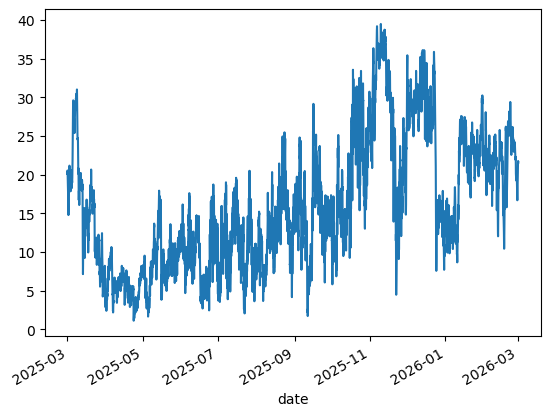

In [17]:
lvl0_filtered_by_depth_sum['percentage_total_ke_[%]'].plot(label=f'{str_depth_min}-{str_depth_max}m')

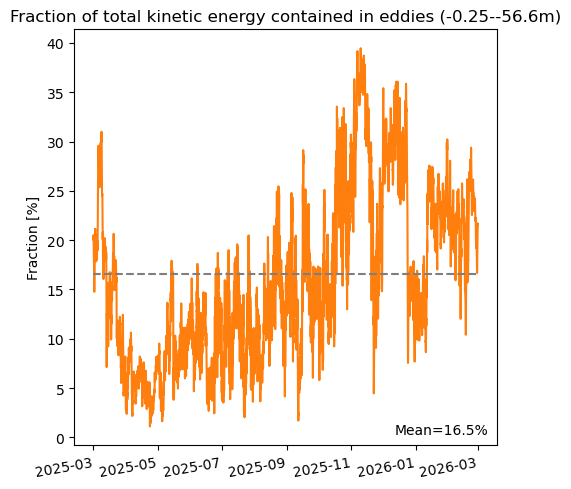

In [18]:
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
lvl0_filtered_by_depth_sum['percentage_total_ke_[%]'].plot(label=f'', c=plot_colors.eddy_color)
plt.hlines(annual_mean_filtered_by_depth,
           lvl0_filtered_by_depth_sum['percentage_total_ke_[%]'].index[0],
           lvl0_filtered_by_depth_sum['percentage_total_ke_[%]'].index[-1],
           linestyles='dashed',
           color='tab:grey')

plt.text(0.98,0.02,f'Mean={annual_mean_filtered_by_depth:.1f}%', transform=plt.gca().transAxes, ha='right', va='bottom')

plt.title(f'Fraction of total kinetic energy contained in eddies ({str_depth_min}-{str_depth_max}m)')
plt.ylabel('Fraction [%]')
plt.xlabel('')
plt.xticks(rotation=10)
plt.tight_layout()
fig.savefig(os.path.join(output_folder, f"fraction_ke_{str_depth_min}-{str_depth_max}m.png"))

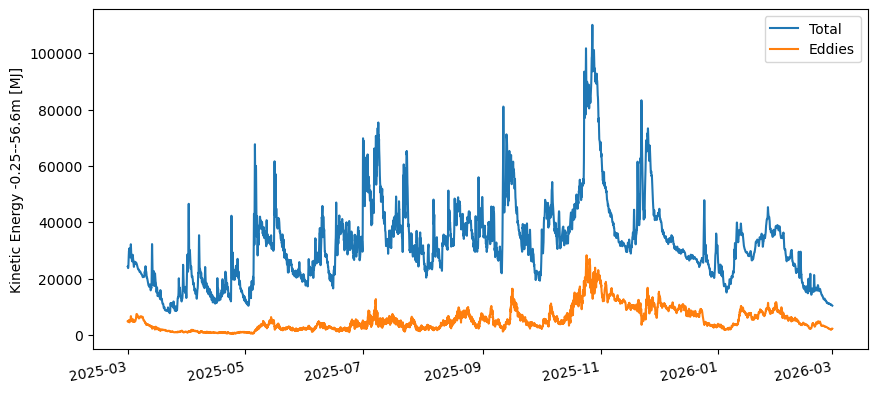

In [19]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 1, 1)
lake_filtered_by_depth_sum['kinetic_energy_[MJ]'].plot(label='Total')
lvl0_filtered_by_depth_sum['kinetic_energy_eddy_[MJ]'].plot(label='Eddies')
plt.legend()
plt.ylabel(f'Kinetic Energy {str_depth_min}-{str_depth_max}m [MJ]')
plt.xlabel('')
plt.xticks(rotation=10)
#ax.set_yscale('log')
fig.savefig(os.path.join(output_folder, f"kinetic_energy_{str_depth_min}-{str_depth_max}m.png"))

NameError: name 'eddy_ke' is not defined

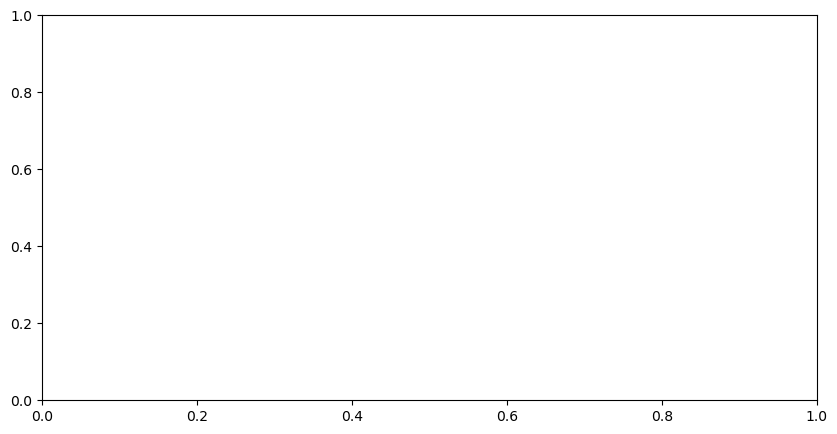

In [20]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1, 1, 1)
eddy_ke.plot(label='Entire depth')
lvl0_filtered_by_depth_sum['kinetic_energy_eddy_[MJ]'].plot(label=f'{str_depth_min}-{str_depth_max}m')
plt.legend()
plt.title('Kinetic Energy contained in eddies')
plt.ylabel(f'Kinetic Energy [MJ]')
plt.xlabel('')
plt.xticks(rotation=10)
fig.savefig(os.path.join(output_folder, f"eddy_kinetic_energy_{str_depth_min}-{str_depth_max}m.png"))

# Horizontal distribution

In [ ]:
da_ke = xr.open_dataarray(os.path.join(base_path, 'energy_budget', 'kinetic_energy.nc'))

In [ ]:
da_eddy_mask = xr.open_dataarray(os.path.join(base_path, 'outputs_swirl', 'eddy_catalogues_final', 'eddy_mask.nc'))

In [ ]:
import dask.array as da

da_ke = da_ke.chunk({"time": 24, "Z": 1, "YC": 180, "XC": 288})
da_eddy_mask = da_eddy_mask.chunk({"time": 24, "Z": 1, "YC": 180, "XC": 288})


In [ ]:
da_ke_horizontal_sum = da_ke.sum(dim=['time'])
da_ke_horizontal_sum.to_netcdf(os.path.join(base_path, 'energy_budget', 'sum_ke.nc'))

In [ ]:
da_ke_eddy = da_ke.where(da_eddy_mask)

In [ ]:
da_ke_eddy_horizontal_sum = da_ke_eddy.sum(dim=['time'])

In [ ]:
da_ke_eddy_horizontal_sum.to_netcdf(os.path.join(base_path, 'energy_budget', 'sum_ke_eddy.nc'))

In [ ]:
da_ke_eddy_horizontal_sum = xr.open_dataarray(os.path.join(base_path, 'energy_budget', 'sum_ke_eddy.nc'))

In [ ]:
import numpy as np

In [ ]:
plt.figure(figsize=(10,5))
horizontal_sum = da_ke_eddy_horizontal_sum.sum(dim=['Z'])
horizontal_sum.where(horizontal_sum>0, np.nan).plot(cmap='jet', cbar_kwargs={'label': 'Kinetic Energy [J]'})
plt.title('Annual Vertically Integrated Eddy Kinetic Energy')

# Vertical distribution

In [ ]:
da_ke = xr.open_dataarray(os.path.join(base_path, 'energy_budget', 'kinetic_energy.nc'))

In [ ]:
profile_mean_lake_ke = da_ke.sum(dim=['time', 'YC', 'XC'])

In [ ]:
cumsum_ke_lake = profile_mean_lake_ke.iloc[::-1].cumsum().iloc[::-1]
(cumsum_ke_lake/ cumsum_ke_lake.max()).plot()

In [ ]:
profile_mean_lake_ke[profile_mean_lake_ke.index > -50].sum()/profile_mean_lake_ke.sum()